In [11]:
import sys
sys.path.insert(0, '../../')

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import h5py
import pickle
import bluepyopt
import os
os.chdir("neuron_genetic_alg/neuron_files/bbp")
from neuron import h
os.chdir("../../../")
os.chdir("./neuron_genetic_alg/")
from config import *
import math
import hoc_utils
os.chdir("../")

# cwd = os.getcwd()
# os.chdir("/pscratch/sd/z/zladd/axonstandardized/playground/runs/bbp_full_11_27_22_487664663/genetic_alg/neuron_genetic_alg/")
# from neuron import h
# os.chdir(cwd)

import plot_helper as ph


In [2]:
plt.rcParams['svg.fonttype'] = "none"


In [3]:
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

tick_major = 6
tick_minor = 4
plt.rcParams["xtick.major.size"] = tick_major
plt.rcParams["xtick.minor.size"] = tick_minor
plt.rcParams["ytick.major.size"] = tick_major
plt.rcParams["ytick.minor.size"] = tick_minor

font_small = 12
font_medium = 13
font_large = 14
plt.rc('font', size=font_small)          # controls default text sizes
plt.rc('axes', titlesize=font_medium)    # fontsize of the axes title
plt.rc('axes', labelsize=font_medium)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=font_small)    # fontsize of the tick labels
plt.rc('ytick', labelsize=font_small)    # fontsize of the tick labels
plt.rc('legend', fontsize=font_small)    # legend fontsize
plt.rc('figure', titlesize=font_large)   # fontsize of the figure title

# Plot for GA result
def final_indv_plot(param_names, final_best_indv, title, file_path_to_save=None, max_xtic=1, vert_size=10):
    plt.figure(figsize=(cm_to_in(8.5), cm_to_in(vert_size)))
    ax = plt.gca()
    y_pos = np.arange(len(param_names))
    ax.barh(y_pos, final_best_indv, height=0.5, align='center', linestyle='-', color='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(param_names)
    ax.invert_yaxis()  # labels read top-to-bottom
    plt.axvline(x=0, color='black', linewidth=0.4 ,linestyle='--')
    ax.set_xlim(0, max_xtic)
    ax.set_xticks([0, max_xtic])
    ax.set_ylabel('Parameters')
    ax.set_xlabel('Normalized Distance')
    ax.set_title('Deviation From Truth Value ' + title)
    if file_path_to_save:
        plt.savefig(file_path_to_save+'.pdf', format='pdf', dpi=1000, bbox_inches="tight")

# Code for optimization results analysis
def read_and_normalize_with_neg(opt_result_path, base, lower_bounds, upper_bounds):
    with open(opt_result_path, 'rb') as f:
        best_indvs = pickle.load(f, encoding = "latin1")
    normalized_indvs = []
    for i in range(len(best_indvs)):
        normalized = []
        for j in range(len(best_indvs[i])):
            if (best_indvs[i][j] < base[j]):
                new_value = abs((best_indvs[i][j] - base[j])/(ubs[j] - base[j]))
                normalized.append(new_value)
            else:
                new_value = abs((best_indvs[i][j] - base[j])/(ubs[j] - base[j]))
                normalized.append(new_value)
        normalized_indvs.append(normalized)
    return normalized_indvs, best_indvs

def plot_stim_volts_pair(stim, volts, title_stim, title_volts, file_path_to_save=None):
    plt.figure(figsize=(cm_to_in(8.5+6), cm_to_in(12)))
    plt.subplot(2, 1, 1)
    plt.title(title_stim)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (nA)')
    plt.plot(stim, color='black', linewidth=0.7)
    plt.subplot(2, 1, 2)
    plt.title('Voltage Response '+title_volts)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (mV)')
    plt.plot(volts[0], label='target', color='black')
    plt.plot(volts[1], label='best individual', color='crimson')
    plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout(pad=1)
    if file_path_to_save:
        plt.savefig(file_path_to_save+'.pdf', format='pdf', dpi=1000, bbox_inches="tight")

def cm_to_in(cm):
    return cm/2.54

# Running a single volt
def run_single_volts(param_set, stim_data, ntimestep = 10000, dt = 0.02):
    run_file = 'neuron_genetic_alg/neuron_files/bbp/run_model_cori.hoc'
    h.load_file(run_file)
    total_params_num = len(param_set)
    timestamps = np.array([dt for i in range(ntimestep)])
    h.curr_stim = h.Vector().from_python(stim_data)
    h.transvec = h.Vector(total_params_num, 1).from_python(param_set)
    h.stimtime = h.Matrix(1, len(timestamps)).from_vector(h.Vector().from_python(timestamps))
    h.ntimestep = ntimestep
    h.runStim()
    out = h.vecOut.to_python()
    return np.array(out)

def plot_comb_scores(opt_path, score_path, title, plot_save_path=None):
    opt_result = h5py.File(opt_path)
    ordered_score_function_list = [e.decode('ascii') for e in opt_result['ordered_score_function_list'][:]]
    optimization_stim_names = [e.decode('ascii') for e in opt_result['opt_stim_name_list'][:]]
    optimization_weightes = opt_result['opt_weight_list'][:]
    best_stims_score_list = []
    for score_name in optimization_stim_names:
        curr_score_data = h5py.File(score_path+score_name+'_scores.hdf5', 'r')
        for sf in ordered_score_function_list:
            curr_stim_sf_pair = curr_score_data['norm_pin_scores_'+sf][:]
            best_stims_score_list.append(curr_stim_sf_pair)
    combined_score = sum([best_stims_score_list[i]*optimization_weightes[i] for i in range(len(optimization_weightes))])
    plt.figure(figsize=(cm_to_in(8.5), cm_to_in(5)))
    plt.title(title)
    plt.xlabel('Parameter Set Rank')
    plt.ylabel('Weighted Score')
    time_step = range(len(combined_score))
    plt.scatter(time_step, combined_score, s=1, color='black')
    if plot_save_path:
        plt.savefig(plot_save_path+'.pdf', format='pdf', dpi=1000, bbox_inches="tight")


In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
test_stim1_name = 'chirp_f_0_to_0.1_a_3_to_9'
test_stim1_name = 'chirp_f_0.12_to_0_a_3_to_3'

test_stim2_name = 'he_1_1_18'
# test_stim2_name = 'he_1_1_2'

stims = h5py.File('../stims/stims_full_TMP_while_I_run_reproduce_stims.hdf5', 'r')
test_stim1 = stims[test_stim1_name][:]
test_stim2 = stims[test_stim2_name][:]

## Full Parameters Analysis

### Score function

FileNotFoundError: [Errno 2] No such file or directory: './plots_prev_bounds/scores_bbp_full.pdf'

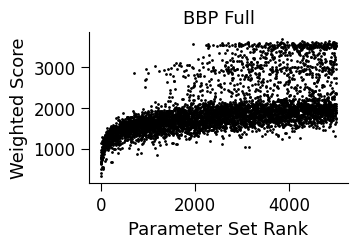

In [7]:
bbp_full_opt_path = './objectives/multi_stim_without_sensitivity_bbp_full_09_30_25_stims.hdf5'
bbp_full_score_path = '../scores/'
bbp_full_plot_path = './plots_prev_bounds/scores_bbp_full'
plot_comb_scores(bbp_full_opt_path, bbp_full_score_path, 'BBP Full', bbp_full_plot_path)
print('Stims used to train:')
train_stim_names_full = h5py.File(bbp_full_opt_path, 'r')['opt_stim_name_list'][:]
for e in train_stim_names_full:
    print(e.decode('ascii'))


### Genetic algorithm result

In [13]:
peeling_step = 'full'

# multistim
GA_result_path = '/pscratch/sd/z/zladd/axonstandardized_v2/neuroncompare/neuroncompare/runs/bbp_full_09_30_25_test/genetic_alg/neuron_genetic_alg/best_indv_logs30019/best_indvs_gen_1.pkl'
log_params=False
peeling_ind_full_bbp = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 22, 23] # bbp Full
task = "multi-stim"






params_path =  '../params/params_bbp_'+peeling_step+'.hdf5'
base_full = h5py.File(params_path, 'r')['orig_'+peeling_step][0]
base = [base_full[i] for i in peeling_ind_full_bbp]
lbs = np.array([0.01*p for p in base])
ubs = np.array([100*p for p in base])
params_bbp_full = [ph.params_bbp[i] for i in peeling_ind_full_bbp]
normalized_indvs_full_bbp, best_indvs_full_bbp = read_and_normalize_with_neg(GA_result_path, base, lbs, ubs)
file_path_to_save = './plots_prev_bounds/GA_bbp_full'
# ph.final_indv_plot(params_bbp_full, normalized_indvs_full_bbp[-1], 'For Full Parameters', file_path_to_save, 1, 18)
# for i in range(len(base)):
#     ph.normalized_indvs_bbp_overall[peeling_ind_full_bbp[i]] = normalized_indvs_full_bbp[-1][i]
#     ph.best_indvs_bbp_overall[peeling_ind_full_bbp[i]] = best_indvs_full_bbp[-1][i]
    

In [14]:
bases, orig_params, mins, maxs = hoc_utils.log_params(ubs, lbs, base_full)

In [15]:

# def unlog_params(data,bases):
#     unlogged_data = []
#     for indv in range(len(data)):
#         params = data[indv]
#         for i, opt_ind in enumerate(params):
#             if bases[i] > 50:
#                 params[i] = math.pow(bases[i], params[i])
#         unlogged_data.append(params)
#     return unlogged_data
    
# with open(GA_result_path,'rb') as f:
#     data = np.array(pickle.load(f))

# unlogged = unlog_params(data,bases)

# with open(os.path.join(os.path.dirname(GA_result_path),'unlogged.pkl'),'wb') as f:
#     pickle.dump(data,f)


### Train stim response

In [16]:
best_full = list(base_full)
for i in range(len(peeling_ind_full_bbp)):
    best_full[peeling_ind_full_bbp[i]] = best_indvs_full_bbp[-1][i]
    
if True:
    for i, opt_ind in enumerate(peeling_ind_full_bbp):
        if bases[i] > 50:
            best_full[opt_ind] = math.pow(bases[i], best_full[opt_ind])



chirp_f_0.12_to_0_a_3_to_9
	1 
	1 
Setting temperature to 34.000000 C
Setting simulation time step to 0.025000 ms
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
/pscratch/sd/z/zladd/axonstandardized_v2/neuroncompare/neuroncompare/runs/bbp_full_09_30_25_test/genetic_alg/neuron_genetic_alg/neuron_files/bbp/
	1 
	1 
calculating  
8e-05	0.026145	0.004226	8e-05	0.000143	
3.13797	0.089259	0.00291	0.006827	0.007104	
0.00099	0.973538	1.02195	287.199	0.008752	
0.000609	0.303472	0.008407	0.000994	0.983955	
8e-05	210.485	0.000333	3e-05	
0.026145 
0.004226 
finshed run matrix
calculating  
8e-05	0.00621064	0.000452151	0.000903235	0.00117273	
2.54512	1.33143	0.00291	0.00650554	0.563966	
0.000197766	8.73897	6.15454	287.199	0.00211646	
0.000609	0.210704	0.000274699	0.000677979	6.74404	
6.25627e-06	210.485	0.0150822	2.22099e-05	
0.0062106379 
0.00045215131 


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

finshed run matrix


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

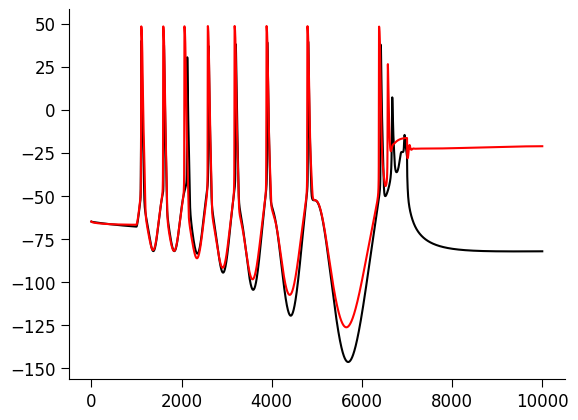

In [17]:
train_stim1_name_full = 'chirp_f_0.12_to_0_a_3_to_9'

# train_stim1_name_full = train_stim_names_full[0]
print(train_stim1_name_full)
train_stim1_full = stims[train_stim1_name_full][:]
train_volts_full_target = run_single_volts(base_full, train_stim1_full)
train_volts_full_best_response = run_single_volts(best_full, train_stim1_full)
file_save_path = './plots_prev_bounds/train_bbp_full'
# ph.plot_stim_volts_pair(train_stim1_full, [train_volts_full_target[0], train_volts_full_best_response[0]], train_stim1_name_full.decode('ascii')+' (Training)', 'for Full Parameters', file_save_path)
fig = plt.figure()
plt.plot(train_volts_full_target, color='black')
plt.plot(train_volts_full_best_response, color='red')
fig.savefig(f"{task}_{train_stim1_name_full}.svg")

he_3_15_12
calculating  
8e-05	0.026145	0.004226	8e-05	0.000143	
3.13797	0.089259	0.00291	0.006827	0.007104	
0.00099	0.973538	1.02195	287.199	0.008752	
0.000609	0.303472	0.008407	0.000994	0.983955	
8e-05	210.485	0.000333	3e-05	
0.026145 
0.004226 


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

finshed run matrix
calculating  
8e-05	0.00621064	0.000452151	0.000903235	0.00117273	
2.54512	1.33143	0.00291	0.00650554	0.563966	
0.000197766	8.73897	6.15454	287.199	0.00211646	
0.000609	0.210704	0.000274699	0.000677979	6.74404	
6.25627e-06	210.485	0.0150822	2.22099e-05	
0.0062106379 
0.00045215131 
finshed run matrix


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


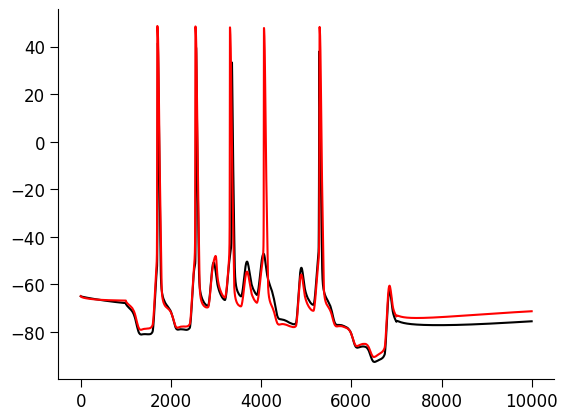

In [18]:
train_stim1_name_full = 'he_3_15_12'
print(train_stim1_name_full)
train_stim1_full = stims[train_stim1_name_full][:]
train_volts_full_target = run_single_volts(base_full, train_stim1_full)
train_volts_full_best_response = run_single_volts(best_full, train_stim1_full)
file_save_path = './plots_prev_bounds/train_bbp_full'
# ph.plot_stim_volts_pair(train_stim1_full, [train_volts_full_target[0], train_volts_full_best_response[0]], train_stim1_name_full.decode('ascii')+' (Training)', 'for Full Parameters', file_save_path)
fig = plt.figure()
plt.plot(train_volts_full_target, color='black')
plt.plot(train_volts_full_best_response, color='red')
fig.savefig(f"{task}_{train_stim1_name_full}.svg")

In [19]:
best_full

[8e-05,
 0.006210637863927671,
 0.0004521513076888179,
 0.0009032352595402493,
 0.0011727306953056994,
 2.5451237171993406,
 1.331430470700654,
 0.00291,
 0.006505544902488417,
 0.5639660685644533,
 0.00019776588493690894,
 8.738973768484831,
 6.154538620637659,
 287.198731,
 0.0021164601228631625,
 0.000609,
 0.21070424075390085,
 0.00027469861947142807,
 0.0006779793557893583,
 6.744040450134441,
 6.256268000443094e-06,
 210.485284,
 0.015082208402503952,
 2.2209861763320287e-05]

b'chirp_f_0.12_to_0_a_3_to_9'


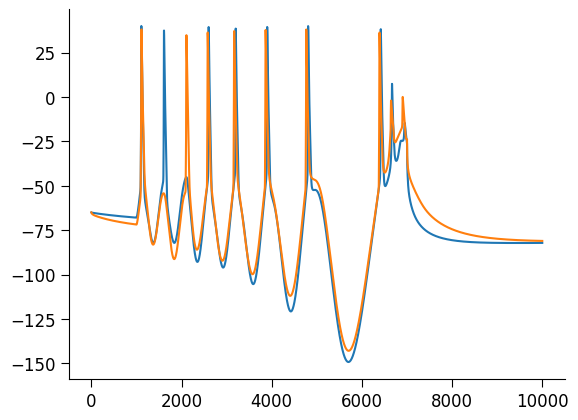

In [72]:
train_stim1_name_full = train_stim_names_full[0]
print(train_stim1_name_full)
train_stim1_full = stims[train_stim1_name_full][:]
train_volts_full_target = run_single_volts(base_full, train_stim1_full)
train_volts_full_best_response = run_single_volts(best_full, train_stim1_full)
file_save_path = './plots_prev_bounds/train_bbp_full'
# ph.plot_stim_volts_pair(train_stim1_full, [train_volts_full_target[0], train_volts_full_best_response[0]], train_stim1_name_full.decode('ascii')+' (Training)', 'for Full Parameters', file_save_path)
plt.plot(train_volts_full_target)
plt.plot(train_volts_full_best_response)


### Test stim response

In [10]:
# test_volts_full_target1, _ = ph.run_single_volts(base_full, test_stim1)
# test_volts_full_best_response1, _ = ph.run_single_volts(best_full, test_stim1)
# file_save_path = './plots_prev_bounds/test_bbp_full_stim1'
# ph.plot_stim_volts_pair(test_stim1, [test_volts_full_target1, test_volts_full_best_response1], test_stim1_name+' (Testing)', 'for Full Parameters', file_save_path)

# test_volts_full_target2, _= ph.run_single_volts(base_full, test_stim2)
# test_volts_full_best_response2, _ = ph.run_single_volts(best_full, test_stim2)
# file_save_path = './plots_prev_bounds/test_bbp_full_stim2'
# ph.plot_stim_volts_pair(test_stim2, [test_volts_full_target2, test_volts_full_best_response2], test_stim2_name+' (Testing)', 'for Full Parameters', file_save_path)



In [38]:
data[-1]

(99, 19)